# Vizsgaeredmények elemzése

## Történet
Egyetemi hallgatókat vizsgálunk, és az a célunk, hogy előre jelezzük a vizsgaeredményüket különböző tényezők alapján.  
Az adatok szintetikusak, de a valós élethez hasonló helyzetet modelleznek.

## Változók
- **study_hours** – heti tanulási órák száma (numerikus)  
- **sleep_hours** – átlagos napi alvásórák száma (numerikus)  
- **attendance** – az órákon való részvétel aránya százalékban (numerikus)  
- **exam_result** – a vizsgaeredmény kategóriája (0, 1, 2):
  - 0 = sikertelen vizsga
  - 1 = átlagos teljesítmény
  - 2 = kiemelkedő teljesítmény

## 1. feladat: Adatok beolvasása

Olvasd be a **`vizsga.csv`** fájlt pandas segítségével egy DataFrame-be, és nézd meg az első néhány sort, hogy ellenőrizd az adatokat.

In [2]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import sklearn
pd.set_option('display.max_columns', None)

df = pd.read_csv('vizsga.csv')
df.head(10)

,study_hours,sleep_hours,attendance,exam_result
0,4.551272,5.211525,52.138567,0
1,3.034304,5.843133,57.146551,0
2,3.844058,5.837208,58.536935,0
3,5.590056,5.095367,52.809602,0
4,3.898110,4.550885,57.914558,0
5,3.720699,5.469180,56.258639,0
6,5.272587,5.119505,57.115185,0
7,4.787739,6.064846,60.358928,0
8,3.354541,4.715041,53.562533,0
9,4.044896,4.541246,53.613580,0


## 2. feladat: Bináris logisztikus regresszió a teljesítmény alapján

Ebben a feladatban a vizsgaeredményeket két kategóriára egyszerűsítjük:

- **rosszul teljesítők** = `exam_result == 0`  
- **jól teljesítők** = `exam_result == 2`  

A cél:  
1. Hozz létre egy új adathalmazt csak ezekkel a két kategóriával.  
2. Taníts rá egy **logisztikus regressziót**, ahol a független változók: `study_hours` és `sleep_hours`.  
3. Vizualizáld az előrejelzett valószínűségeket valamilyen változó (pl. `study_hours`) függvényében.

<Axes: xlabel='study_hours', ylabel='sleep_hours'>

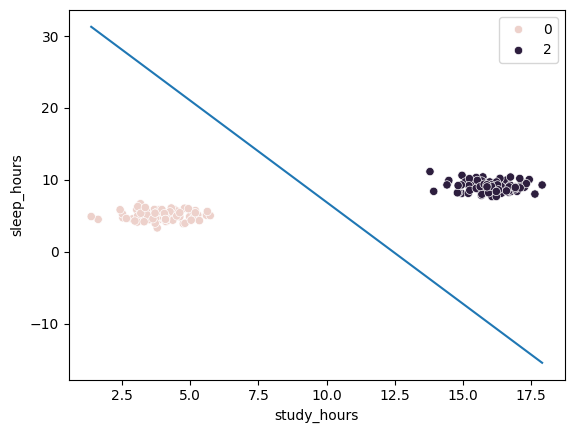

In [4]:
df_new = df[df['exam_result'].isin([0,2])]
df_new.head(10)

from sklearn.linear_model import LogisticRegression

X = df_new[['study_hours','sleep_hours']].to_numpy()
X[:10]

y = df_new['exam_result'].to_numpy()
y[:10]

reg = LogisticRegression()
reg.fit(X,y)

theta0 = reg.intercept_
theta1 = reg.coef_[0,0]
theta2 = reg.coef_[0,1]

x2 = -(theta0+theta1*df_new['study_hours'])/theta2
sns.scatterplot(x=df_new['study_hours'],y=df_new['sleep_hours'],hue=y)
sns.lineplot(x=df_new['study_hours'],y=x2)